# 1) Chargement des données

Allez, cadeau 😘:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, FunctionTransformer

DATA_PATH = "/content/billets.csv"

if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")
    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)
    print("⚠️ Tu as bien lu le code avant de l'executer ? 😏")


✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


# 2) Analyse exploratoire (EDA)


Là, c'est vous les pro 💪, je vous fais entièrement confiance 😉 !

Pssst (indice) : trouvez des variables corrélées à votre objectif, ça marche mieux 😉.

### 2.1 - Analyse exploratoire du fichier

In [2]:
#renommer is_genuine
df = df.rename(columns={"is_genuine": "counterfeit"})

In [3]:
#On remplace True par 1 et False par 0 dans is_genuine
df["counterfeit"] = df["counterfeit"].replace({True: 0, False: 1})
display(df.head())

/tmp/ipykernel_4660/5329381.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["counterfeit"] = df["counterfeit"].replace({True: 0, False: 1})


,counterfeit,diagonal,height_left,height_right,margin_low,margin_up,length
0,0,171.81,104.86,104.95,4.52,2.89,112.83
1,0,171.46,103.36,103.66,3.77,2.99,113.09
2,0,172.69,104.48,103.50,4.40,2.94,113.16
3,0,171.36,103.91,103.94,3.62,3.01,113.51
4,0,171.73,104.28,103.46,4.04,3.48,112.54


In [4]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est de : ",df.shape[1],"\n")
#La nature des données dans chacune des colonnes
print("Nature des données pour chaques colonnes :\n", df.dtypes,"\n")
#Le nombre de valeurs présentes dans chacune des colonnes
print("Nombre de valeurs par colonnes :\n", df.count())

Le nombre de colonnes est de :  7 

Nature des données pour chaques colonnes :
 counterfeit       int64
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object 

Nombre de valeurs par colonnes :
 counterfeit     1500
diagonal        1500
height_left     1500
height_right    1500
margin_low      1463
margin_up       1500
length          1500
dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   counterfeit   1500 non-null   int64  
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 82.2 KB


In [6]:
#On remplace les NAn par la moyenne
df["margin_low"].fillna(df["margin_low"].mean(), inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   counterfeit   1500 non-null   int64  
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1500 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 82.2 KB


/tmp/ipykernel_4660/2955708248.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["margin_low"].fillna(df["margin_low"].mean(), inplace=True)


In [7]:
df.describe()

,counterfeit,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,0.333333,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.471562,0.305195,0.299462,0.325627,0.655569,0.231813,0.87273
min,0.000000,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,0.000000,171.750000,103.820000,103.710000,4.030000,2.990000,112.03000
50%,0.000000,171.960000,104.040000,103.920000,4.330000,3.140000,112.96000
75%,1.000000,172.170000,104.230000,104.150000,4.860000,3.310000,113.34000
max,1.000000,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


### 2.2 - Création de variables intéressantes

In [8]:
#L'aire
df["Area"] = round(df["length"] * ((df["height_right"]+df["height_left"])/2),2)
display(df.head())

,counterfeit,diagonal,height_left,height_right,margin_low,margin_up,length,Area
0,0,171.81,104.86,104.95,4.52,2.89,112.83,11836.43
1,0,171.46,103.36,103.66,3.77,2.99,113.09,11705.95
2,0,172.69,104.48,103.50,4.40,2.94,113.16,11767.51
3,0,171.36,103.91,103.94,3.62,3.01,113.51,11796.53
4,0,171.73,104.28,103.46,4.04,3.48,112.54,11689.53


In [9]:
#Différence des tailles
df["diff_height"] = abs(round(df["height_right"] - df["height_left"],2))
display(df.head())

,counterfeit,diagonal,height_left,height_right,margin_low,margin_up,length,Area,diff_height
0,0,171.81,104.86,104.95,4.52,2.89,112.83,11836.43,0.09
1,0,171.46,103.36,103.66,3.77,2.99,113.09,11705.95,0.30
2,0,172.69,104.48,103.50,4.40,2.94,113.16,11767.51,0.98
3,0,171.36,103.91,103.94,3.62,3.01,113.51,11796.53,0.03
4,0,171.73,104.28,103.46,4.04,3.48,112.54,11689.53,0.82


In [10]:
# Différence des marges
df["diff_margin"] = abs(round(df["margin_up"] - df["margin_low"],2))
display(df.head())

,counterfeit,diagonal,height_left,height_right,margin_low,margin_up,length,Area,diff_height,diff_margin
0,0,171.81,104.86,104.95,4.52,2.89,112.83,11836.43,0.09,1.63
1,0,171.46,103.36,103.66,3.77,2.99,113.09,11705.95,0.30,0.78
2,0,172.69,104.48,103.50,4.40,2.94,113.16,11767.51,0.98,1.46
3,0,171.36,103.91,103.94,3.62,3.01,113.51,11796.53,0.03,0.61
4,0,171.73,104.28,103.46,4.04,3.48,112.54,11689.53,0.82,0.56


In [11]:
#Somme des marges
df["sum_margin"] = round(df["margin_up"] + df["margin_low"],2)
display(df.head())

,counterfeit,diagonal,height_left,height_right,margin_low,margin_up,length,Area,diff_height,diff_margin,sum_margin
0,0,171.81,104.86,104.95,4.52,2.89,112.83,11836.43,0.09,1.63,7.41
1,0,171.46,103.36,103.66,3.77,2.99,113.09,11705.95,0.30,0.78,6.76
2,0,172.69,104.48,103.50,4.40,2.94,113.16,11767.51,0.98,1.46,7.34
3,0,171.36,103.91,103.94,3.62,3.01,113.51,11796.53,0.03,0.61,6.63
4,0,171.73,104.28,103.46,4.04,3.48,112.54,11689.53,0.82,0.56,7.52


### 2.2 - Visualisation des répartitions

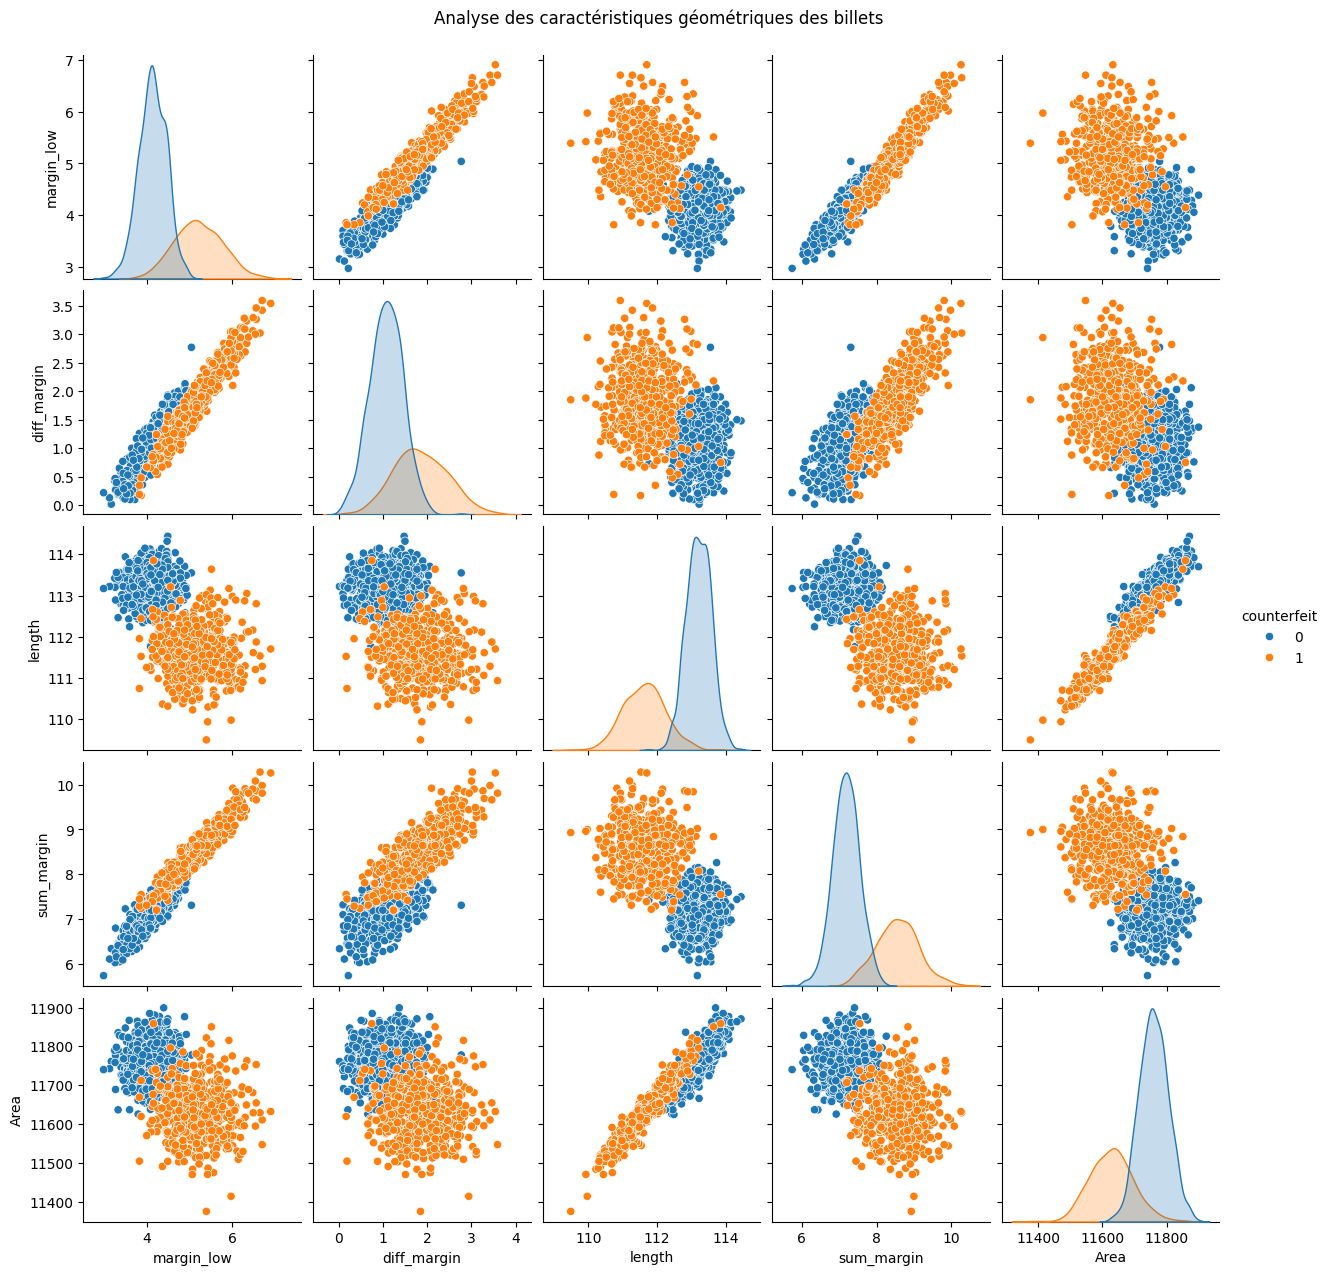

In [12]:
cols = ['margin_low', 'diff_margin', 'length','sum_margin','Area', 'counterfeit']
sns.pairplot(df[cols], hue='counterfeit')

plt.suptitle("Analyse des caractéristiques géométriques des billets", y=1.02)
plt.show()

### 2.3 Vérification des outliers

In [13]:
# IQR pour les margins
import numpy as np
iqr = np.quantile(df.margin_up, q=[0.25, 0.75])
limite_basse = round(iqr[0] - 1.5*(iqr[1] - iqr[0]),2)
limite_haute = round(iqr[1] + 1.5*(iqr[1] - iqr[0]),2)

print("limite_haute margin_up:", limite_haute, "mm")
print("limite_basse margin_up:", limite_basse, "mm")

#afficher le nombre de valeurs qui dépassent
print("Nombre de valeurs qui dépassent la limite haute margin_up:", df[df.margin_up > limite_haute].shape[0])
print("Nombre de valeurs qui dépassent la limite basse margin_up:", df[df.margin_up < limite_basse].shape[0], "\n")

iqr = np.quantile(df.margin_low, q=[0.25, 0.75])
limite_basse = round(iqr[0] - 1.5*(iqr[1] - iqr[0]),2)
limite_haute = round(iqr[1] + 1.5*(iqr[1] - iqr[0]),2)

print("limite_haute margin_low:", limite_haute, "mm")
print("limite_basse margin_low:", limite_basse, "mm")

#afficher le nombre de valeurs qui dépassent
print("Nombre de valeurs qui dépassent la limite haute margin_low:", df[df.margin_low > limite_haute].shape[0])
print("Nombre de valeurs qui dépassent la limite basse margin_low:", df[df.margin_low < limite_basse].shape[0])

limite_haute margin_up: 3.79 mm
limite_basse margin_up: 2.51 mm
Nombre de valeurs qui dépassent la limite haute margin_up: 2
Nombre de valeurs qui dépassent la limite basse margin_up: 1 

limite_haute margin_low: 6.1 mm
limite_basse margin_low: 2.78 mm
Nombre de valeurs qui dépassent la limite haute margin_low: 26
Nombre de valeurs qui dépassent la limite basse margin_low: 0


### 2.4 Matrice de corrélation

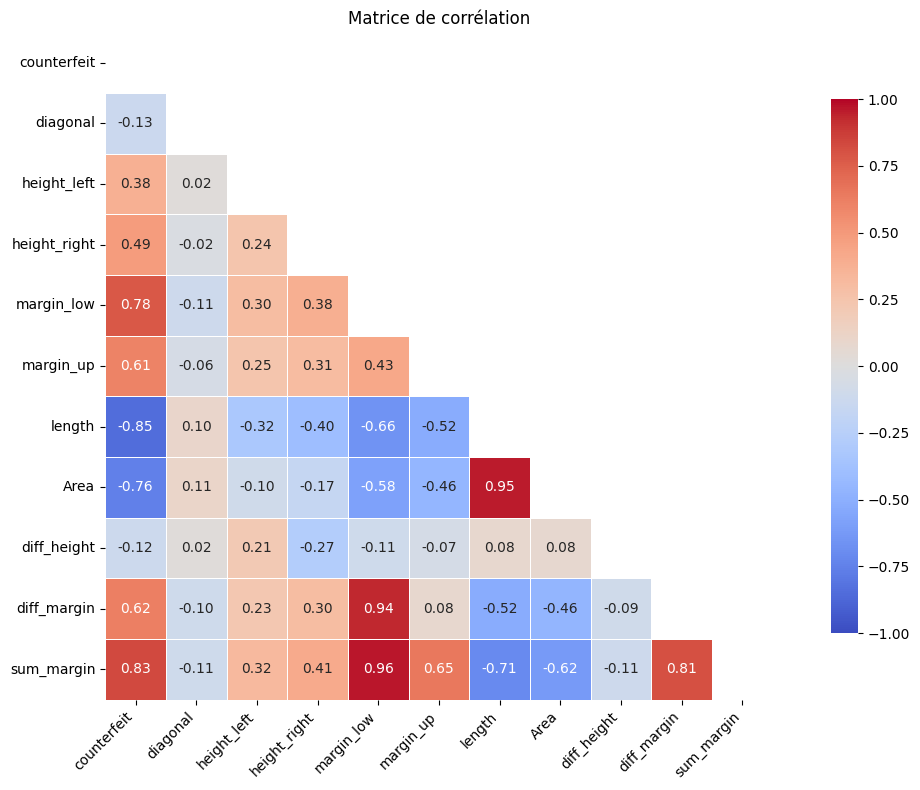

In [14]:
corr = df.select_dtypes(include="number").drop(columns=["cluster"], errors="ignore").corr()

# masque du triangle supérieur
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.


D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

➡️ Pourquoi ?
Parce que le modèle doit apprendre à prédire y en fonction de X.

In [15]:
X = df.drop(columns=["counterfeit"]) # Toutes les colonnes sauf la cible
y = df["counterfeit"]
X.shape

(1500, 10)

Autre point important : on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

➡️ Pourquoi ?
Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d’échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d’importance.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Use scaler on X_train and X_test (on ne fait que la variable x car y est déjà sur une échelle fixe 0 ou 1)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) #on ne fait pas le fit sur le test car sinon fuite de données
pd.DataFrame(X_train).describe().round(2)

,0,1,2,3,4,5,6,7,8,9
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.98,-2.96,-3.37,-2.28,-3.80,-3.64,-4.13,-1.23,-2.19,-2.42
25%,-0.67,-0.70,-0.65,-0.71,-0.69,-0.72,-0.60,-0.75,-0.68,-0.73
50%,0.01,0.03,0.00,-0.24,-0.09,0.33,0.22,-0.28,-0.14,-0.29
75%,0.69,0.66,0.71,0.49,0.69,0.75,0.73,0.51,0.50,0.62
max,3.43,2.82,3.16,3.71,3.28,1.85,2.21,5.03,3.81,3.38


# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

In [18]:
from sklearn.linear_model import LogisticRegression

# 1) Initialisez une régression logistic.
    # Quels sont les paramètres ajustables de ce modèle ? penalty, C,..., il y en a 13 au total
    # Bien que vous puissez laisser la majorité d'entre eux par défaut,
    # il vaut mieux, à minima, ajuster `max_iter` pour plafonner le temps de calcul



# 2) Entrainez le modèle avec vos données X_train et y_train
clf = LogisticRegression(max_iter=80, random_state=8).fit(X_train, y_train)

# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test.
y_pred = clf.predict(X_test)
y_prob_positive = clf.predict_proba(X_test)[:, 1] #obligatoire pour avoir seulement la colonne de probabilité nécéssaire pour le ROC-AUC
print(f"Score Train: {clf.score(X_train, y_train)}")
print(f"Score Test: {clf.score(X_test, y_test)}")

Score Train: 0.9925
Score Test: 0.9933333333333333


Accuracy: 0.9933333333333333
Precision: 1.0
Recall: 0.9818181818181818
ROC-AUC 0.9999043062200956
[[190   0]
 [  2 108]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       190
           1       1.00      0.98      0.99       110

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



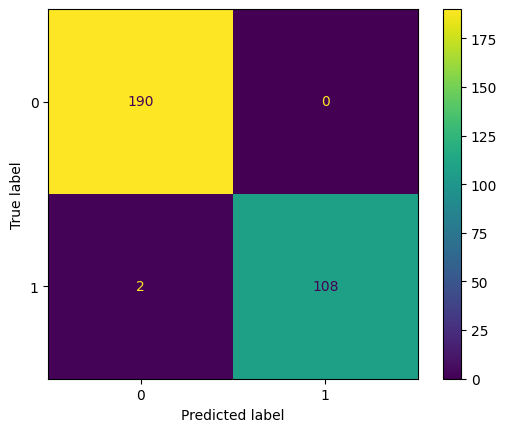

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# C'est là qu'on voit qui sont les bons 😉!

print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("ROC-AUC", roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)

In [20]:
from sklearn.neighbors import KNeighborsClassifier

# Répéter les même étapes que pour la régression logistique mais avec le KNN.
clf = KNeighborsClassifier(n_neighbors=10).fit(X_train, y_train)

# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test.
y_pred = clf.predict(X_test)
y_prob_positive = clf.predict_proba(X_test)[:, 1] #obligatoire pour avoir seulement la colonne de probabilité nécéssaire pour le ROC-AUC
print(f"Score Train: {clf.score(X_train, y_train)}")
print(f"Score Test: {clf.score(X_test, y_test)}")


Score Train: 0.9883333333333333
Score Test: 0.9866666666666667


Accuracy: 0.9866666666666667
Precision: 1.0
Recall: 0.9636363636363636
ROC-AUC 0.9999521531100479
[[190   0]
 [  4 106]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       190
           1       1.00      0.96      0.98       110

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.99       300
weighted avg       0.99      0.99      0.99       300



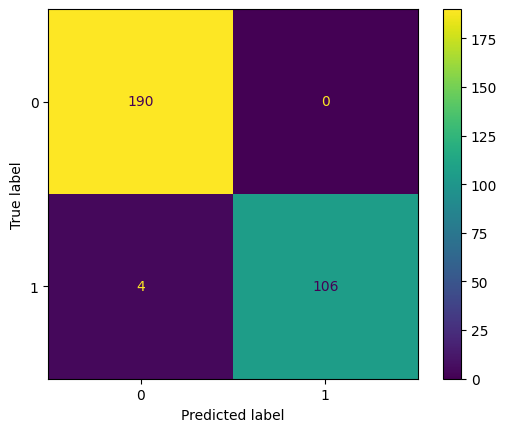

In [21]:
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("ROC-AUC", roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)

In [22]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators = 100, random_state = 8).fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob_positive = clf.predict_proba(X_test)[:, 1] #obligatoire pour avoir seulement la colonne de probabilité nécéssaire pour le ROC-AUC
print(f"Score Train: {clf.score(X_train, y_train)}")
print(f"Score Test: {clf.score(X_test, y_test)}")

Score Train: 1.0
Score Test: 0.99


Accuracy: 0.99
Precision: 1.0
Recall: 0.9727272727272728
ROC-AUC 0.9997607655502392
[[190   0]
 [  3 107]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       190
           1       1.00      0.97      0.99       110

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



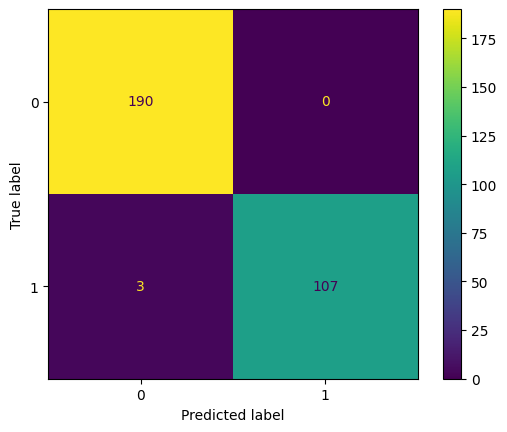

In [23]:
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("ROC-AUC", roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)

In [24]:
from sklearn.cluster import KMeans

# Attention ! Cet algo est très différents de ceux utilisés précédemment.
# Peux-tu voir les différences ?
# Du coup, cet algo est-il utile (voir pertinent) pour cette étude ? le kmeans ne prédit pas, il permet de voir la séparation natutrelle des données

model = KMeans( n_clusters=2, random_state = 8, n_init = 'auto')
model.fit(X_train)

print("score", model.score(X_test))

y_pred_kmeans = model.predict(X_test)
print(pd.Series(y_pred_kmeans).value_counts())
print("Le cluster 1 représente :",round(sum(y_pred_kmeans)/len(X_test)*100,2),"% des données avec le Kmeans")

score -1786.2339446867427
0    194
1    106
Name: count, dtype: int64
Le cluster 1 représente : 35.33 % des données avec le Kmeans


In [59]:
test = model.labels_

#créer une colonne cluster dans y_train avec les valeurs de test
y_tr = y_train.to_frame()
y_tr["cluster"] = test
display(y_tr)

#faire la moyenne par cluster pour counterfeit
cluster1 = y_tr[y_tr['cluster'] == 1]["counterfeit"].mean()
print(cluster1)

#On attribut la bonne catégorie
if round(cluster1*100,2)<50: #si moins de 50% de contrefaçon dans cluster 1 les numéro de cluster sont inversé
  y_pred_corrige = 1 - y_pred_kmeans
else:
  y_pred_corrige = y_pred_kmeans


,counterfeit,cluster
382,0,0
538,0,0
1493,1,1
1112,1,1
324,0,0
...,...,...
1130,1,1
1294,1,1
860,0,0
1459,1,1


0.9973262032085561


           diagonal  height_left  height_right  margin_low  margin_up  \
cluster                                                                 
0        172.001495   103.933969    103.803557    4.145185   3.051701   
1        171.895189   104.195283    104.137925    5.247170   3.340189   

             length          Area  diff_height  diff_margin  sum_margin  
cluster                                                                  
0        113.150773  11752.833247     0.322680     1.093608    7.197010  
1        111.683208  11633.662453     0.317736     1.906981    8.587358  


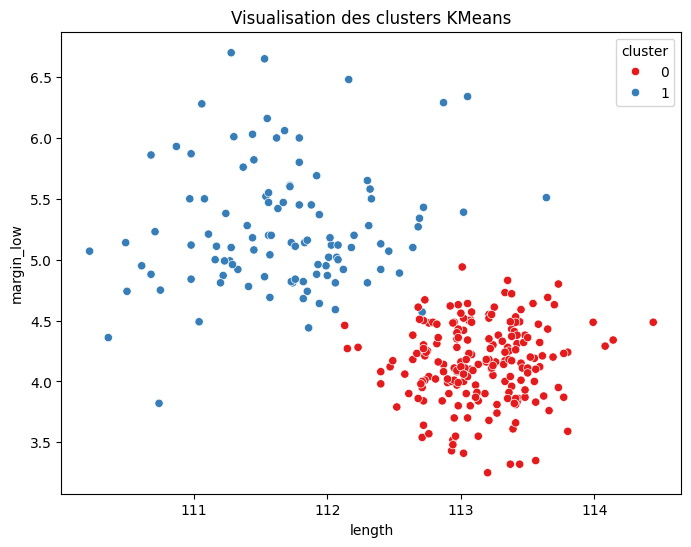

In [55]:
#on affiche les moyennes pour chaque colonne des clusters
df_clusters = pd.DataFrame(X_test, columns=X.columns)
df_clusters["cluster"] = y_pred_kmeans

print(df_clusters.groupby("cluster").mean())

plt.figure(figsize=(8,6))

#graphiue de répartition
sns.scatterplot(
    x=df_clusters["length"],
    y=df_clusters["margin_low"],
    hue=df_clusters["cluster"],
    palette="Set1"
)

plt.title("Visualisation des clusters KMeans")
plt.show()


on voit clairement ici que le cluter 1 qui représente les faux billets est beaucoup plus variable mais avec une taille plus faible et des marge plus grandes

Accuracy: 0.9866666666666667
Precision: 1.0
Recall: 0.9636363636363636
[[190   0]
 [  4 106]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       190
           1       1.00      0.96      0.98       110

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.99       300
weighted avg       0.99      0.99      0.99       300



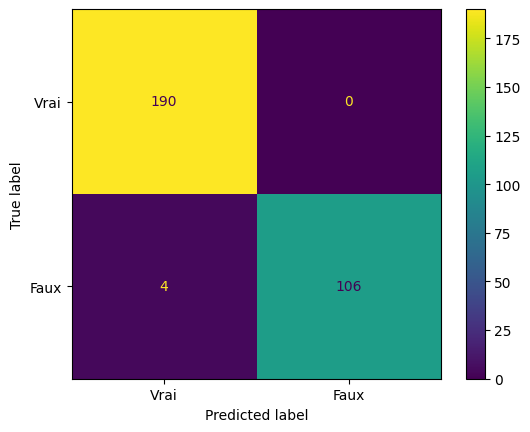

In [58]:
print("Accuracy:",accuracy_score(y_test, y_pred_corrige))
print("Precision:",precision_score(y_test, y_pred_corrige))
print("Recall:",recall_score(y_test, y_pred_corrige))
print(confusion_matrix(y_test, y_pred_corrige))
print(classification_report(y_test, y_pred_corrige))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_corrige, display_labels=['Vrai', 'Faux'])

# Sélection du meilleur modèle

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

Vous me voyez venir... 😎 : StatQuest !!! 🤩
* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Vous avez aussi des petits modules sympathiques sur Sklearn qui vous machent grandement le travail:
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

A vous de jouer ! 🚀

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# C'est là qu'on voit qui sont les bons 😉!

# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

In [65]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
import joblib
from sklearn.compose import ColumnTransformer



# 1. Préparation des données
X = df.drop(columns=["counterfeit"]) # Toutes les colonnes sauf la cible
y = df["counterfeit"] # 0 = Vrai, 1 = Faux (comme tu l'as défini)

# 3. Création du Pipeline intelligent
mon_pipeline_complet = make_pipeline(
    StandardScaler(),                        # Étape 1 : Standardise les 10 colonnes
    LogisticRegression(max_iter=80, random_state=8) # Étape 2 : on applique le modèle
)

# 4. Entraînement et Sauvegarde
mon_pipeline_complet.fit(X, y)
joblib.dump(mon_pipeline_complet, 'modele_final.joblib')

print("✅ Modèle sauvegardé !")

✅ Modèle sauvegardé !


In [30]:
from google.colab import files
files.download('modele_final.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Version améliorée

In [72]:
import cloudpickle

def add_custom_features(X):
    X = X.copy()
    #L'aire
    X["Area"] = X["length"] * ((X["height_right"] + X["height_left"])/2)

    #Différence des tailles
    X["diff_height"] = abs(X["height_right"] - X["height_left"])

    # Différence des marges
    X["diff_margin"] = abs(X["margin_up"] - X["margin_low"])

    #Somme des marges
    X["sum_margin"] = X["margin_up"] + X["margin_low"]

    return X

features_transformer = FunctionTransformer(add_custom_features)

pipeline = Pipeline([
    ("features", features_transformer),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

# 1. Préparation des données
X = df.drop(columns=["counterfeit"]) # Toutes les colonnes sauf la cible
y = df["counterfeit"] # 0 = Vrai, 1 = Faux (comme tu l'as défini)


# 2. Entraînement et Sauvegarde
pipeline.fit(X, y)

with open("modele_final2.pkl", "wb") as f:
    cloudpickle.dump(pipeline, f)

In [73]:
from google.colab import files
files.download('modele_final2.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>